> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# **IS4487 Module 4 - Assignment**

### Outline

Our Goals with this Project:

1. Import the data
2. Examine or profile the data: assess the shape, data types, distributions, missing values or inconsistencies
3. Perform Exploratory Data Analysis (EDA): create visualizations to better understand the variables and relationships in the data

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

For this assignment, the variable `answered` is your target.  


### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


## 🔧 **Task 1: Import the libraries and load the data**

🔧 1.1. Import the libraries you will need, such as:
- Pandas
- Matplotlib
- Seaborn


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

🔧 1.2. Load data

Import data from the AdviseInvest historical dataset into a dataframe.

- In GitHub go to the folder called DataSets, search for a dataset called ***"adviseinvest_historical_data.csv"***
- Click on it and it will take you to a data display page.
- Click on the *'Raw'* button at the top right of the page.
- Then on the next page that follows, copy the url of raw dataset. This is what you want to enter as the url for `pd.read_csv()`



In [13]:
adviseinvest_df = pd.read_csv('https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/main/DataSets/adviseinvest_historical_data.csv')
display(adviseinvest_df.head(15))

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0
5,1,14030,0,28,2,1,1,0,1.0,0,0,2,0,4
6,1,9320,0,24,2,1,0,1,0.0,3,0,2,0,2
7,1,11750,0,68,0,1,0,0,1.0,1,0,0,0,3
8,1,69670,0,36,3,1,1,0,0.0,1,1,3,0,4
9,1,3380,0,52,2,1,0,1,0.0,0,2,4,0,4


## **Task 2: Initial Data Understanding: examine or profile the data**

🔧 2.1. Obtain the shape of the table (rows and columns).

🔧 2.2. Profile the dataframe - obtain data types, counts of variables, missing values.

🔧 2.3. Are there any duplicate rows?

🔧 2.4. Describe the dataframe (i.e. obtain min, max, mean, std dev, percentiles etc).



In [3]:
adviseinvest_df.shape

(29504, 14)

In [4]:
adviseinvest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


In [5]:
adviseinvest_df.duplicated().sum()

np.int64(29035)

In [6]:
adviseinvest_df.describe()

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


### 🔧Please answer the following:

2.5. Do you see any variables that have potential outliers? What indicators do you see the the values are out of the normal range? (don't worry about using a scientific approach for outliers at this stage; just use your best judgment)

### ✍️ Your response: 🔧

2.5.  Income and age may have potential outliers. The minimum income is -65,600, which is unusual because income is normally not negative. The maximum income is 159,450, which is much higher than the 75th percentile of 41,690. The maximum age is 132, which is outside the normal age range and may be a data error. The num_accts variable also has an unusually large value, which may be a data error.




## **Task 3: Explore the data - create visualizations**

Explore the relationships between the target and independent variables. You can assume that  `Answered` is the target variable.

🔧 3.1. - 3.5. Create at least five charts to show the relationships, using different chart types that are approriate to the analysis. Ensure that all charts are clearly labeled and formatted

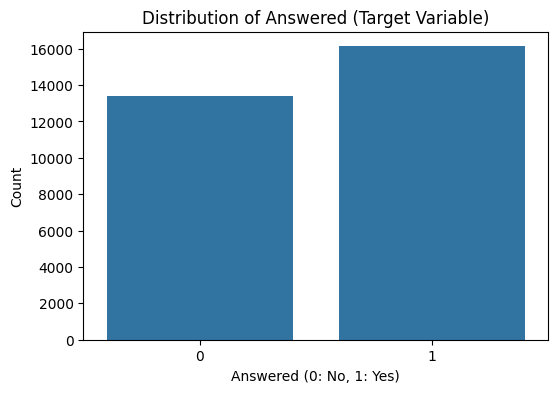

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='answered', data=adviseinvest_df)
plt.title('Distribution of Answered (Target Variable)')
plt.xlabel('Answered (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

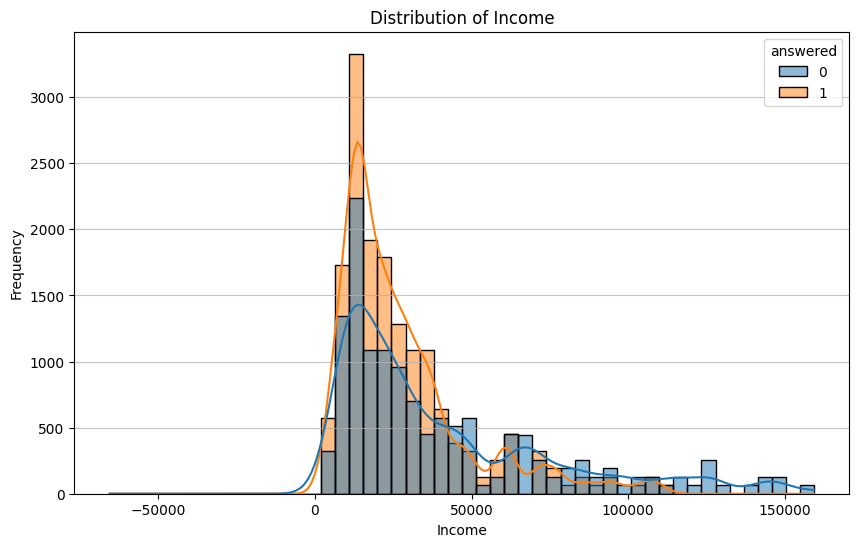

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=adviseinvest_df, x='income', hue='answered', bins=50, kde=True)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

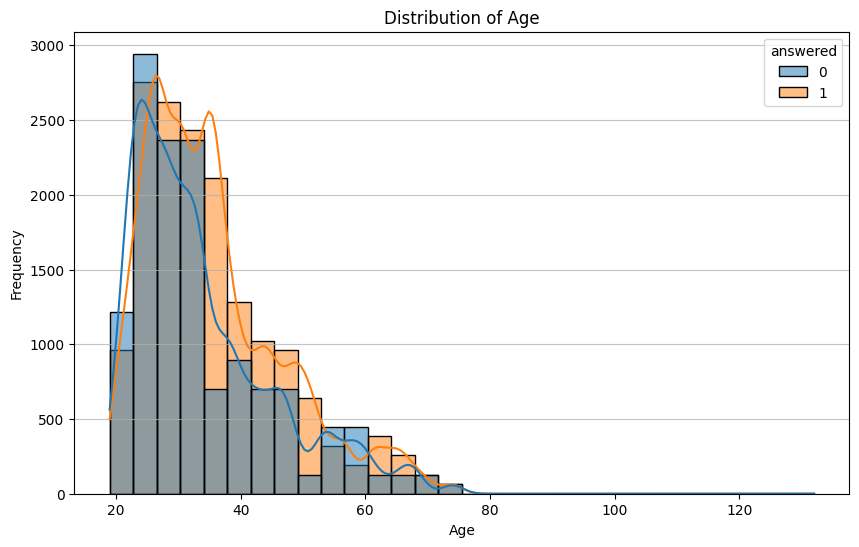

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data=adviseinvest_df, x='age', hue='answered', bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

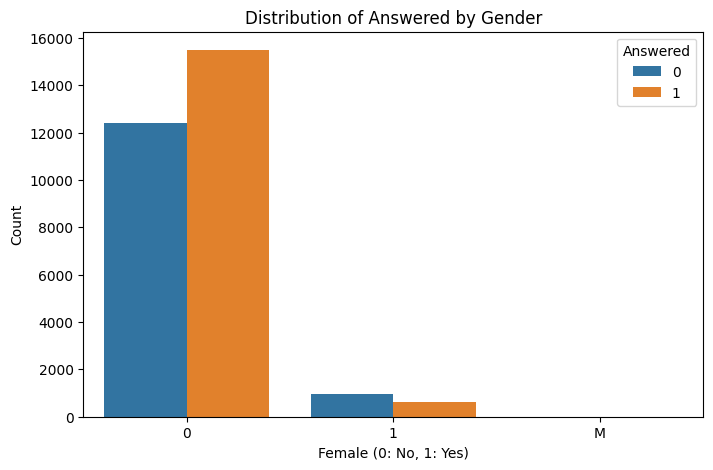

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(x='female', hue='answered', data=adviseinvest_df)
plt.title('Distribution of Answered by Gender')
plt.xlabel('Female (0: No, 1: Yes)')
plt.ylabel('Count')
plt.legend(title='Answered')
plt.show()

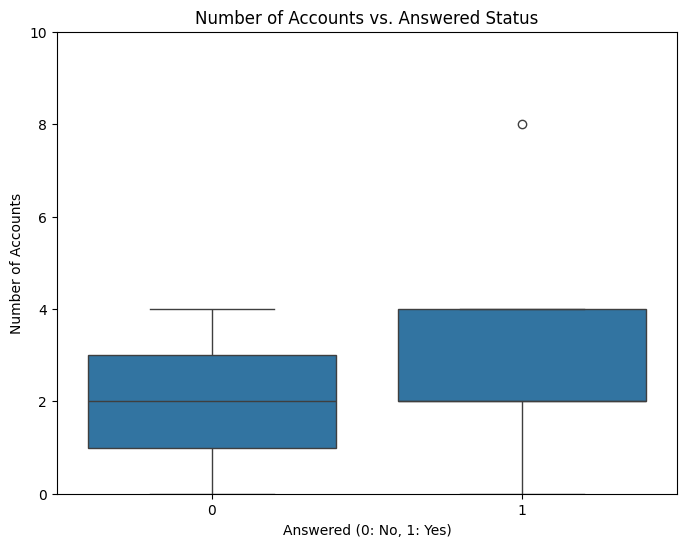

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='answered', y='num_accts', data=adviseinvest_df)
plt.title('Number of Accounts vs. Answered Status')
plt.xlabel('Answered (0: No, 1: Yes)')
plt.ylabel('Number of Accounts')
plt.ylim(0, 10) # Limit the Y-axis to better observe the main data distribution
plt.show()

## **Task 4: Summarize Your Findings**

### 🔧 Please answer the following:

 4.1. Are all of the variables useful and applicable to the business need? Why? explain briefly. (you should reference the target variable and whether other variables we have are likely to be correlated with the target)

 4.2: In what ways could the dataset be improved?  Are there any data quality issues or data types that should be fixed?

### ✍️ Your response: 🔧

4.1. I do not think all variables are equally useful. The target variable is answered, which shows whether a customer answered the call. Variables such as number of accounts, age, and income may be related to whether a customer answers. More analysis is needed to know which variables are useful.


4.2  The dataset could be improved by checking unusual values, missing values, and data types. There are some unusually large values in age and number of accounts, and income has negative values. new_car has two missing values. Also, female has inconsistent values and should be changed to the correct data type.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully in your own words
- Save the file with your last name and first name as shown below (see detailed instructions in Lab 1 on how to do this).
- Submit the assignment as an **HTML file** on Canvas

In [24]:
!jupyter nbconvert --to html "assignment_04_Gong Linlin.ipynb"

[NbConvertApp] Converting notebook assignment_04_Gong Linlin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 526759 bytes to assignment_04_Gong Linlin.html
